In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,f1_score,recall_score


In [3]:
df=sns.load_dataset('iris')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.shape

(150, 5)

In [6]:
df['sepal_length_width_ratio']=df['sepal_length']/df['sepal_width']
df['petal_length_width_ratio']=df['petal_length']/df['petal_width']

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length_width_ratio,petal_length_width_ratio
0,5.1,3.5,1.4,0.2,setosa,1.457143,7.0
1,4.9,3.0,1.4,0.2,setosa,1.633333,7.0
2,4.7,3.2,1.3,0.2,setosa,1.468750,6.5
3,4.6,3.1,1.5,0.2,setosa,1.483871,7.5
4,5.0,3.6,1.4,0.2,setosa,1.388889,7.0


In [13]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [19]:
X=df.drop('species',axis=1).values
y=df.loc[:,'species'].values

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
encoder=LabelEncoder()

In [25]:
y=encoder.fit_transform(y)

In [26]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
X_train=st.fit_transform(X_train)

In [29]:
X_test=st.transform(X_test)

In [30]:
X_train

array([[-1.47286067e+00,  1.25077879e+00, -1.55015743e+00,
        -1.30727768e+00, -1.63848641e+00,  3.05440933e-01],
       [-1.42305379e-01,  3.06041620e+00, -1.26565907e+00,
        -1.03952201e+00, -1.59574322e+00, -2.35702676e-01],
       [ 1.06729034e+00,  1.19755416e-01,  3.84431392e-01,
         2.99256336e-01,  4.97885058e-01, -4.98543858e-01],
       [-1.23094153e+00,  7.98369443e-01, -1.20875940e+00,
        -1.30727768e+00, -1.31450023e+00,  1.60418559e+00],
       [-1.71477982e+00,  3.45960092e-01, -1.37945841e+00,
        -1.30727768e+00, -1.40339888e+00,  9.54813264e-01],
       [ 2.15592649e+00, -1.06449259e-01,  1.63622416e+00,
         1.23640118e+00,  1.39750112e+00, -4.98543858e-01],
       [ 7.04411626e-01,  3.45960092e-01,  4.41331063e-01,
         4.33134170e-01,  1.07878096e-01, -5.60388842e-01],
       [-7.47103240e-01,  1.02457412e+00, -1.26565907e+00,
        -1.30727768e+00, -1.13568696e+00,  1.38772815e+00],
       [-9.89022384e-01,  1.25077879e+00, -1.322

In [32]:
# logistic Regression
logreg=LogisticRegression(C=0.0001,solver='lbfgs',max_iter=100)
logreg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.0001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [33]:
predictions_lr=logreg.predict(X_test)

In [48]:
cm_lr=confusion_matrix(y_test,predictions_lr)

In [49]:
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0, 11,  0]])

In [50]:
f1_lr=f1_score(y_test,predictions_lr,average='micro')
f1_lr

0.6333333333333333

In [51]:
prec_lr=precision_score(y_test,predictions_lr,average='micro')
prec_lr

0.6333333333333333

In [52]:
recall_lr=recall_score(y_test,predictions_lr,average='micro')
recall_lr

0.6333333333333333

In [53]:
# Accuracy
train_ac_lr=logreg.score(X_train,y_train)
train_ac_lr

0.6638655462184874

In [54]:
test_acc_lr = logreg.score(X_test, y_test) * 100
test_acc_lr

63.33333333333333

In [55]:
# Random Forest
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
predictions_rf = rf_reg.predict(X_test)
predictions_rf

array([1.02, 0.  , 2.  , 1.  , 1.24, 0.  , 1.  , 2.  , 1.08, 1.  , 2.  ,
       0.  , 0.  , 0.  , 0.  , 1.05, 1.9 , 1.  , 1.  , 2.  , 0.  , 1.87,
       0.  , 1.86, 2.  , 1.98, 1.97, 1.93, 0.  , 0.  ])

In [56]:

# Convert predictions to class labels
predictions_rf_class = np.round(predictions_rf).astype(int)
predictions_rf_class

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [57]:

f1_rf = f1_score(y_test, predictions_rf_class, average='micro')
prec_rf = precision_score(y_test, predictions_rf_class, average='micro')
recall_rf = recall_score(y_test, predictions_rf_class, average='micro')

In [58]:
# Accuracy
train_acc_rf = rf_reg.score(X_train, y_train) * 100
test_acc_rf = rf_reg.score(X_test, y_test) * 100

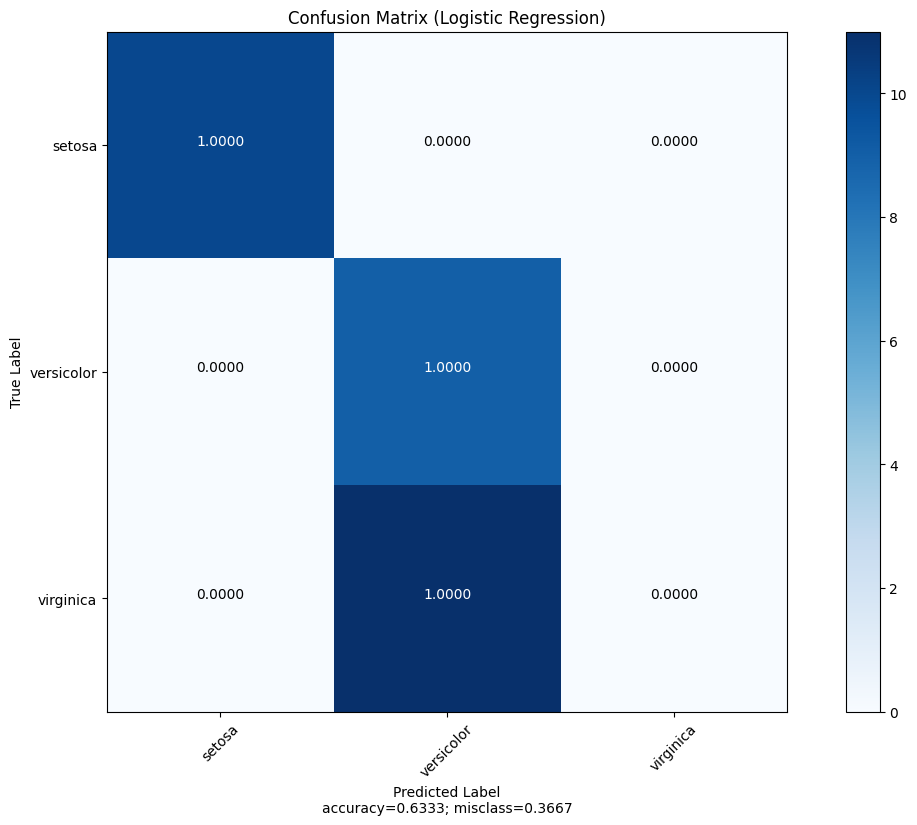

In [59]:
def plot_cm(cm, target_name, title="Confusion Matrix", cmap=None, normalize=True):
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy
    cmap = plt.get_cmap('Blues')
    plt.figure(figsize=(12, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    if target_name is not None:
        tick_marks = np.arange(len(target_name))
        plt.xticks(tick_marks, target_name, rotation=45)
        plt.yticks(tick_marks, target_name)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else 'black')
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.savefig('ConfusionMatrix.png', dpi=120)
    plt.show()

target_name = np.array(['setosa', 'versicolor', 'virginica'])
plot_cm(cm_lr, target_name, title="Confusion Matrix (Logistic Regression)", cmap=None, normalize=True)


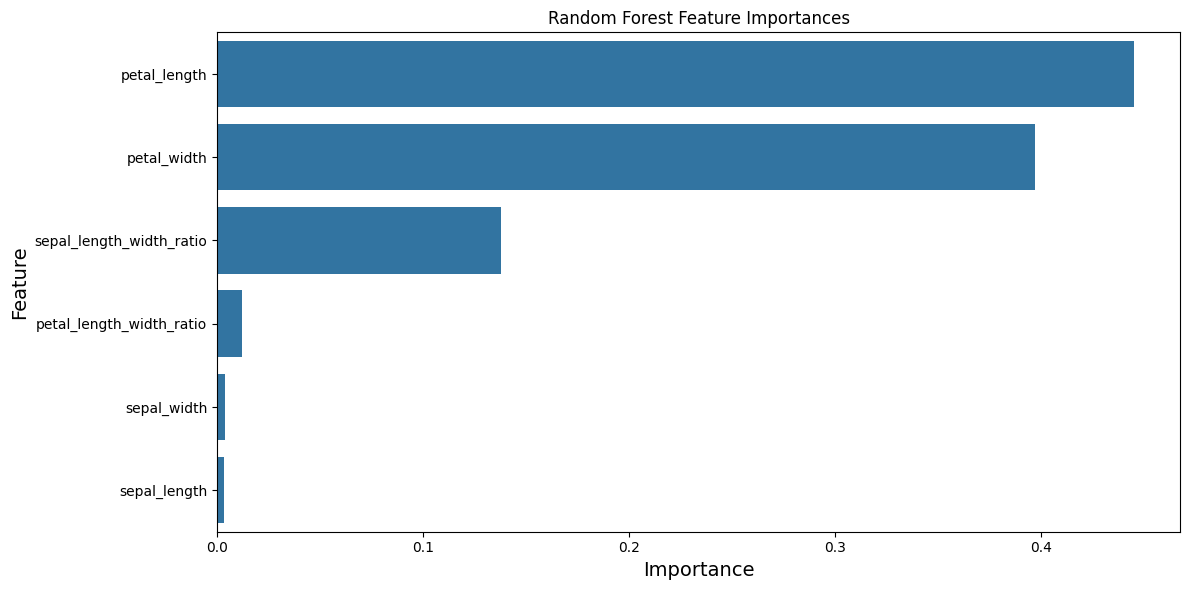

In [60]:
# Feature Importance Plotting
importances = rf_reg.feature_importances_
labels = df.columns[[0,1,2,3,5,6]]  # Exclude 'target' column for features
feature_df = pd.DataFrame(list(zip(labels, importances)), columns=['feature', 'importance'])
features = feature_df.sort_values(by='importance', ascending=False)

# Create feature importance plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='importance', y='feature', data=features)
ax.set_xlabel('Importance', fontsize=14)
ax.set_ylabel('Feature', fontsize=14)
ax.set_title('Random Forest Feature Importances', fontsize=12)

# Show the feature importance plot
plt.tight_layout()  # Make sure layout is adjusted
plt.show()  # 

In [63]:
# Saving Scores to a File
with open('scores.txt', "w") as score:
    score.write("Random Forest Train Var: %2.1f%%\n" % train_acc_rf)
    score.write("Random Forest Test Var: %2.1f%%\n" % test_acc_rf)
    score.write("F1 Score: %2.1f%%\n" % f1_rf)
    score.write("Recall Score: %2.1f%%\n" % recall_rf)
    score.write("Precision Score: %2.1f%%\n" % prec_rf)

    score.write("\n\n")

    score.write("Logistic Regression Train Var: %2.1f%%\n" % train_ac_lr)
    score.write("Logistic Regression Test Var: %2.1f%%\n" % test_acc_lr)
    score.write("F1 Score: %2.1f%%\n" % f1_lr)
    score.write("Recall Score: %2.1f%%\n" % recall_lr)
    score.write("Precision Score: %2.1f%%\n" % prec_lr)